In [1]:
import numpy as np
import sys,os
import glob
import matplotlib.pyplot as plt


importamos la librería  

In [2]:
import jumps_soft as jr


cargamos los datos correspondientes a la observación "skydip" del día 28-05-25

In [3]:
data = np.load('data280525.npz')
tt = data['arr_0']
todarray = data['arr_1']

In [7]:
tt[-1]/60 # aprox 16 minutos de observación

16.417083330949147

Descartamos TES con saturación

In [4]:
sat = jr.saturation() 
sat_mask, sat_idx, sat_frac, n_sat = sat.detect_saturation(todarray)

good_mask = sat_mask
good_idx  = np.where(good_mask)[0]    # index of TES with no saturation
good_tod  = todarray[good_mask, :]    # TOD of good TES

print(good_idx)

[  2   5   7   8   9  10  11  14  15  16  17  18  20  21  22  23  24  25
  26  27  28  29  30  31  32  33  34  35  36  37  38  39  40  41  42  43
  45  46  48  50  52  53  54  55  56  57  58  59  60  61  62  63  64  65
  66  67  68  69  70  71  72  73  74  75  76  77  79  80  81  82  83  84
  85  86  87  88  89  90  91  92  93  94  95  98  99 101 103 105 106 107
 108 110 111 112 114 116 117 118 119 120 121 122 123 124 125 126 127 128
 129 130 131 132 133 134 135 136 137 138 139 140 141 142 144 145 146 147
 148 149 150 153 154 155 156 157 160 161 162 163 165 166 167 168 169 170
 171 172 173 174 175 176 177 179 180 181 182 183 184 185 186 187 188 191
 192 193 194 195 196 197 198 199 200 201 203 204 205 207 208 209 210 211
 212 213 214 216 217 218 219 220 221 222 223 224 227 230 231 233 236 237
 238 239 240 241 243 247 248 250 252 253 254]


In [5]:
print('índices de TES con saturación:', sat_idx)

índices de TES con saturación: [  0   1   3   4   6  12  13  19  44  47  49  51  78  96  97 100 102 104
 109 113 115 143 151 152 158 159 164 178 189 190 202 206 215 225 226 228
 229 232 234 235 242 244 245 246 249 251 255]


Text(0.5, 1.0, 'TES 7')

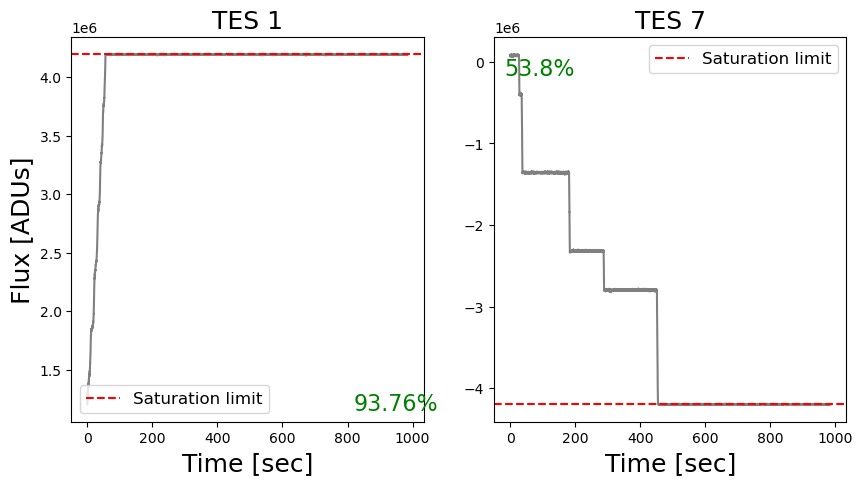

In [6]:
fig, ax = plt.subplots(1,2, figsize=(10,5))

ax[0].plot(tt, todarray[0], color='grey')
ax[0].set_ylabel('Flux [ADUs]', fontsize=18)
ax[0].set_xlabel('Time [sec]', fontsize=18)

ax[0].axhline(y = max(todarray[0]), color= 'red', ls= '--', label='Saturation limit') 
ax[0].legend(fontsize=12, loc ="lower left")
ax[0].text(0.8,0.03, f"{sat_frac[0]*100:.2f}%", transform=ax[0].transAxes, fontsize=16, color='green')
ax[0].set_title('TES 1', fontsize=18)

ax[1].plot(tt, todarray[6], color='grey')
ax[1].axhline(y = min(todarray[6]), color= 'red', ls= '--', label='Saturation limit') 
ax[1].legend(fontsize=12)
ax[1].text(0.03,0.9, f"{sat_frac[6]*100:.1f}%", transform=ax[1].transAxes, fontsize=16, color='green')
ax[1].set_xlabel('Time [sec]', fontsize=18)
ax[1].set_title('TES 7', fontsize=18)

Buscamos flux jumps

In [6]:
thr = 2e5#, 3e5, 5e5]  # Multiple thresholds for better detection
window_size = 500  # Optimized for this dataset length
fluxjumps = jr.fluxjumps(thr=thr, window_size=window_size)

In [7]:
jump_data = {}
for idx_good in good_idx:
    nc, xc, xcf = fluxjumps.jumps_detection(
        todarray[idx_good], 
        consec=True,   # Merge consecutive jumps
        nc_cond=True  # Re-threshold if too many jumps
    )
    jump_data[idx_good] = {'nc': nc, 'xc': xc, 'xcf': xcf}

In [9]:
# Classify TES
TES_yes = [idx for idx in good_idx if jump_data[idx]['nc'] > 0]
TES_no = [idx for idx in good_idx if jump_data[idx]['nc'] == 0]

In [10]:
print('índices de TES con flux jumps encontrados:', TES_yes)

índices de TES con flux jumps encontrados: [7, 10, 14, 20, 54, 55, 76, 121, 157, 205, 222, 224, 233, 237, 238, 254]


In [11]:
xc_7, xcf_7 = jump_data[7]['xc'], jump_data[7]['xcf']
haar_7 = fluxjumps.haar_function(todarray[7])

Text(0, 0.5, 'Flux [ADUs]')

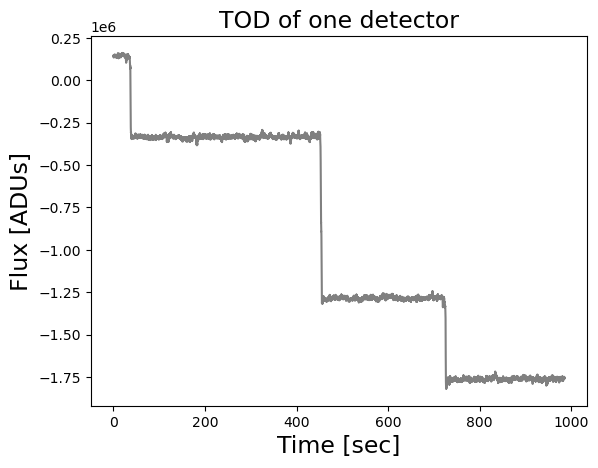

In [12]:
plt.plot(tt, todarray[7], color='gray')
plt.title('TOD of one detector', fontsize=17)
plt.xlabel('Time [sec]', fontsize=17)
plt.ylabel('Flux [ADUs]', fontsize=17)

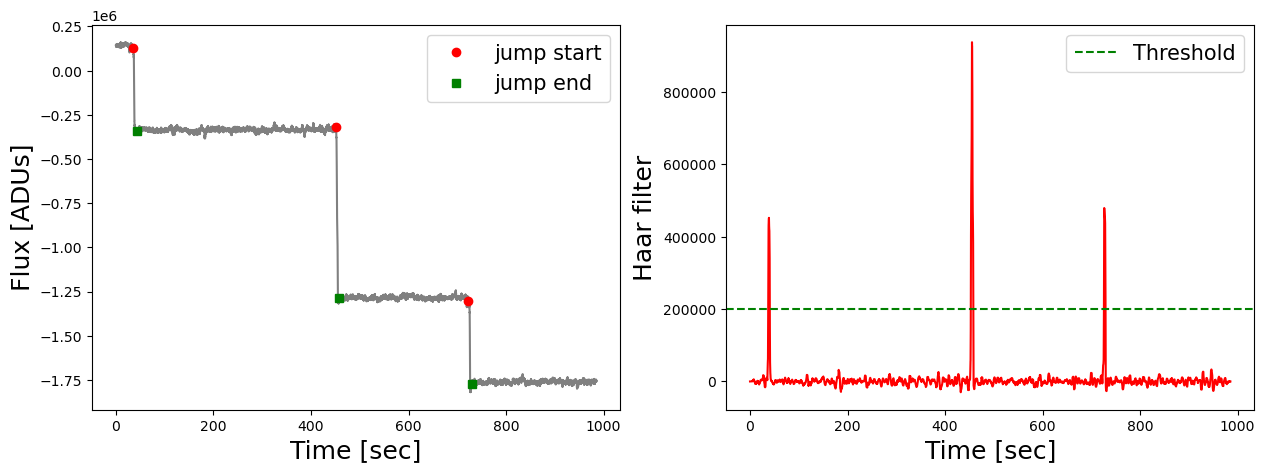

In [14]:
fig, ax = plt.subplots(1,2, figsize=(15, 5))

ax[0].plot(tt, todarray[7], color='grey')
ax[0].plot(tt[xc_7], todarray[7][xc_7], 'o', color='red', label='jump start')
ax[0].plot(tt[xcf_7], todarray[7][xcf_7], 's', color='green', label='jump end')
ax[0].set_xlabel('Time [sec]', fontsize=18)
ax[0].set_ylabel('Flux [ADUs]', fontsize=18)
#ax[0].grid()
ax[0].legend(fontsize=15)

ax[1].plot(tt, haar_7, color='red')
ax[1].set_ylabel('Haar filter', fontsize=18)
ax[1].set_xlabel('Time [sec]', fontsize=18)
ax[1].axhline(y=thr, ls='--', color='green', label='Threshold')
ax[1].legend(fontsize=15)

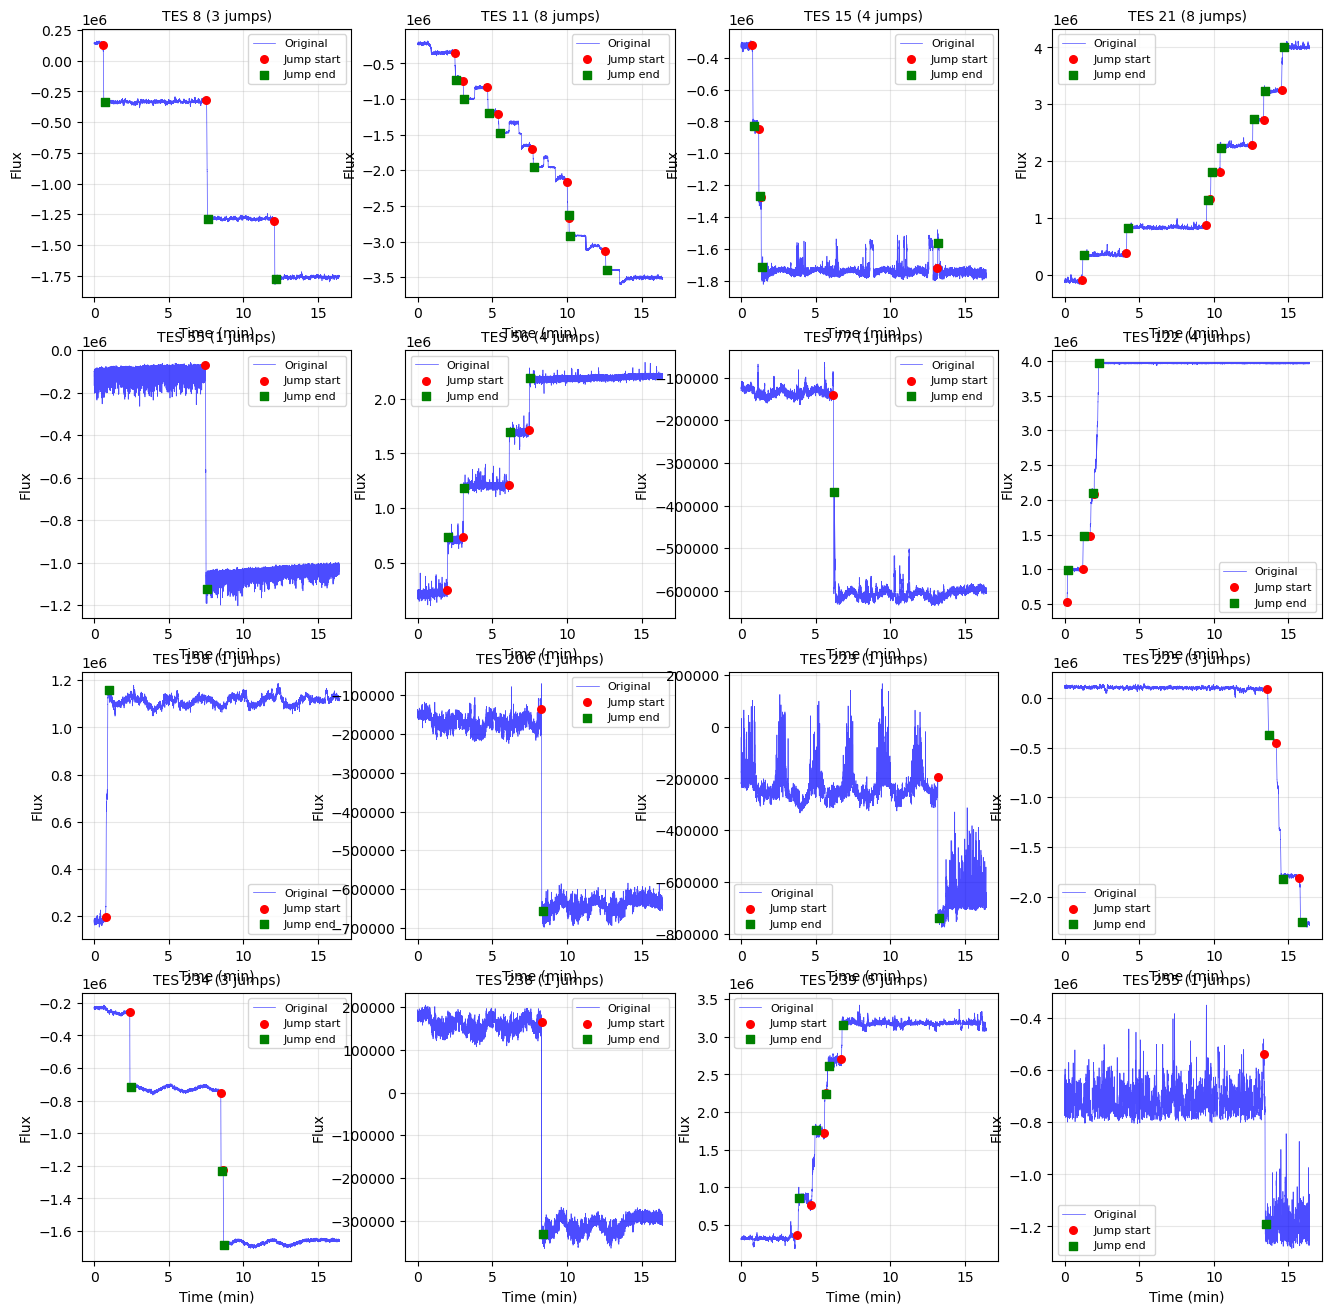

In [15]:
n_plot = len(TES_yes)
n_cols = 4
n_rows = int(np.ceil(n_plot / n_cols))
        
fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))

if n_rows == 1:
    ax = ax.reshape(1, -1)
ax = ax.flatten()
        
plot_idx = 0
for idx in TES_yes[:n_plot]:
    if idx in jump_data:
        ax[plot_idx].plot(tt/60, todarray[idx], 'b-', linewidth=0.5, 
                                 label='Original', alpha=0.7)

        xc = jump_data[idx]['xc']
        xcf = jump_data[idx]['xcf']
        nc = jump_data[idx]['nc']
        if len(xc) > 0:
            ax[plot_idx].scatter(tt[xc]/60, todarray[idx][xc], 
                        color='red', marker='o', s=30, 
                        label='Jump start', zorder=5)
            ax[plot_idx].scatter(tt[xcf]/60, todarray[idx][xcf], 
                        color='green', marker='s', s=30, 
                        label='Jump end', zorder=5)
            ax[plot_idx].set_title(f'TES {idx+1} ({nc} jumps)', fontsize=10)
            ax[plot_idx].set_xlabel('Time (min)')
            ax[plot_idx].set_ylabel('Flux')
            ax[plot_idx].legend(fontsize=8)
            ax[plot_idx].grid(True, alpha=0.3)
            plot_idx += 1


Refinamiento usando decision tree (DT)

In [19]:
import time
t0 = time.time()

In [20]:
dt = jr.DT(thr_count=1000, thr_amp=2e5, tol=1e2, depth=True)
dt_jump_data = {}
TES_with_dt_jumps = []
for idx in TES_yes:
    nc = jump_data[idx]['nc']
    xcdt, xcfdt = dt.calculate_levels(tt, todarray[idx], nc, consec=True)
    dt_jump_data[idx] = {'xcdt': xcdt, 'xcfdt': xcfdt, 'ncdt': len(xcdt)}
    if len(xcdt) > 0:
        TES_with_dt_jumps.append(idx)

In [21]:
t1 = time.time()

In [22]:
print(t1-t0)

2.9981491565704346


In [23]:
xcdt_7, xcfdt_7 = dt_jump_data[7]['xcdt'], dt_jump_data[7]['xcfdt']
ypred7 = dt.define_model(tt, todarray[7], 3)
ypred_unique, index, count = dt.uniqueindex(ypred7)
ypred_unique, index, count = dt.count_filter(ypred_unique, index, count)
        
        # Find level transitions based on amplitude
amplitude, valini, valfin, indexini, indexfin = dt.amplitude_filter(ypred_unique, index, count)

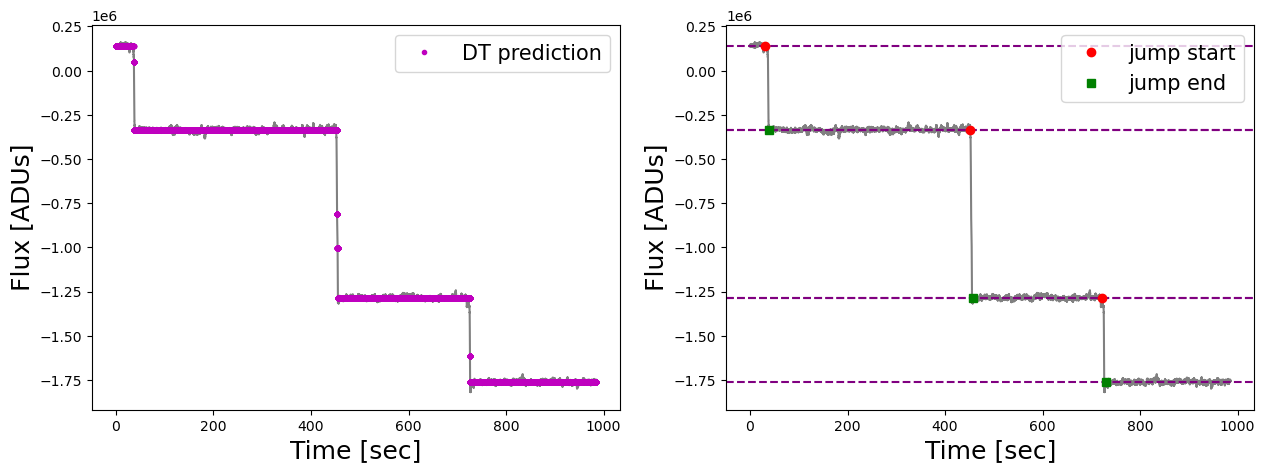

In [24]:
fig, ax = plt.subplots(1,2, figsize=(15, 5))

ax[0].plot(tt, todarray[7], color='grey')
ax[0].plot(tt, ypred7, 'm.', label='DT prediction')
ax[0].set_ylabel('Flux [ADUs]', fontsize=18)
ax[0].set_xlabel('Time [sec]', fontsize=18)
ax[0].legend(fontsize=15)

ax[1].plot(tt, todarray[7], color='gray')
for i in range(len(valini)):
    ax[1].axhline(y=valini[i], ls='--', color='purple')
    ax[1].axhline(y=valfin[i], ls='--', color='purple')
ax[1].plot(tt[xcdt_7], todarray[7][xcdt_7], marker='o', lw=0, color='red', label='jump start')
ax[1].plot(tt[xcfdt_7], todarray[7][xcfdt_7], marker='s', lw=0, color='green', label='jump end')
ax[1].set_ylabel('Flux [ADUs]', fontsize=18)
ax[1].set_xlabel('Time [sec]', fontsize=18)
ax[1].legend(fontsize=15)

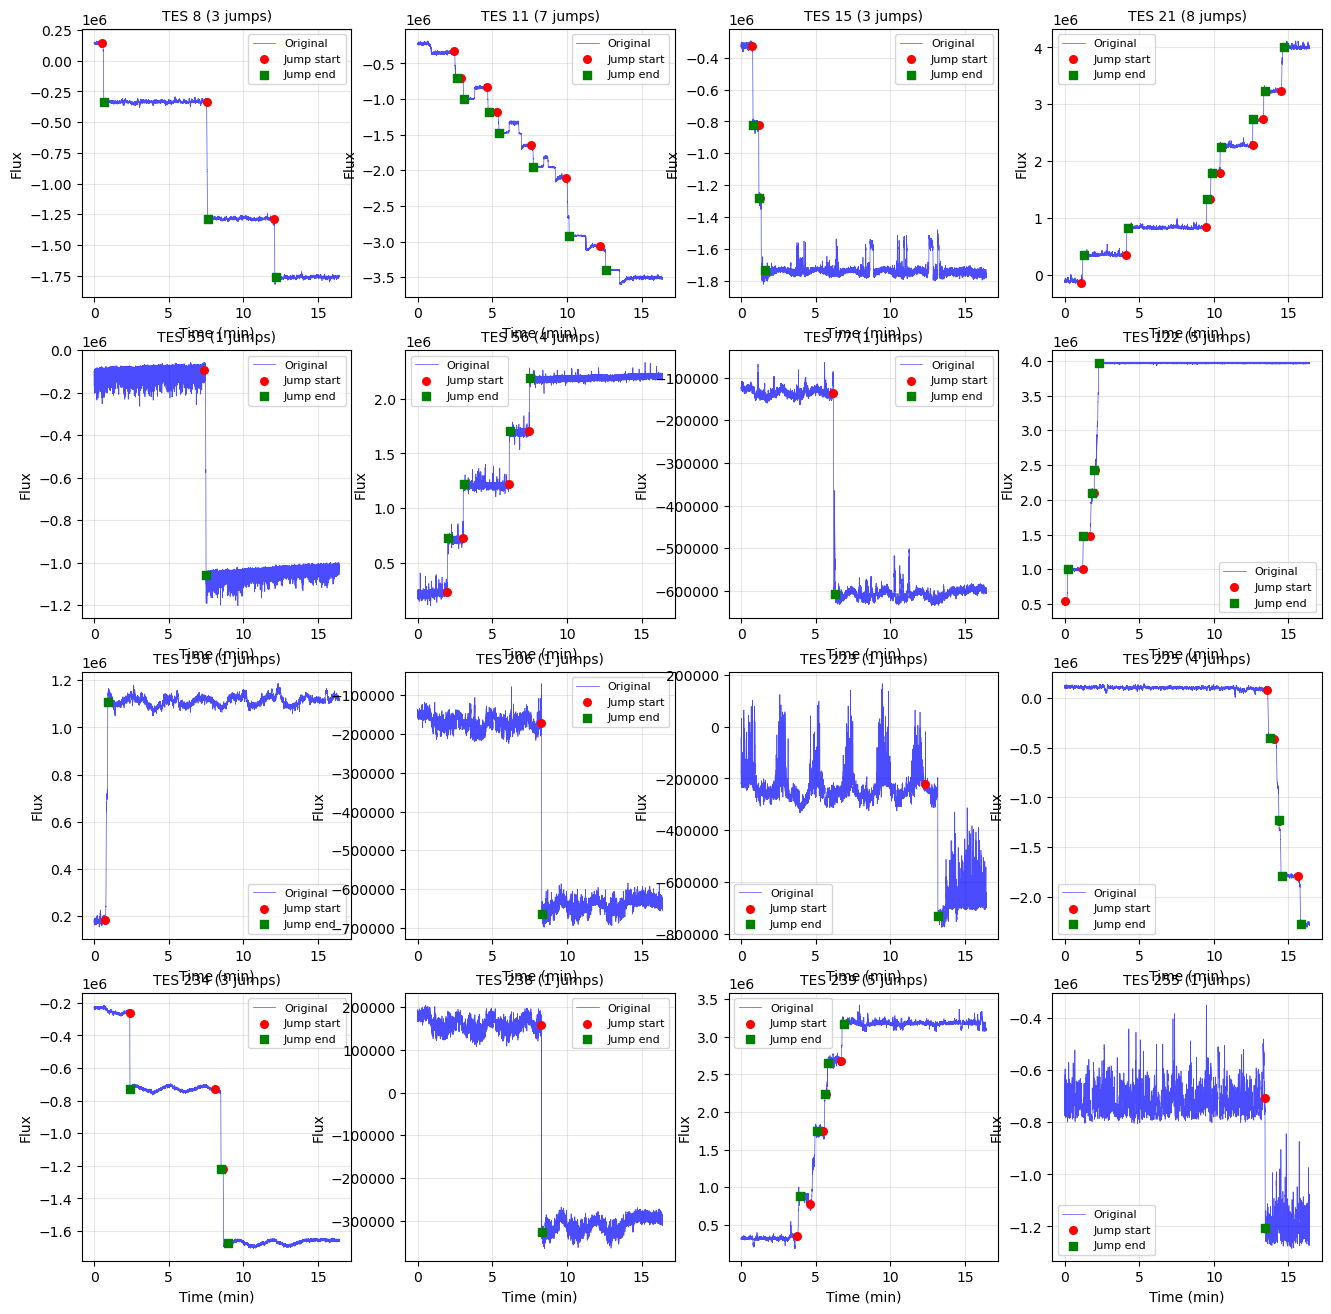

In [25]:
n_plot = len(TES_with_dt_jumps)
n_cols = 4
n_rows = int(np.ceil(n_plot / n_cols))
        
fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))

if n_rows == 1:
    ax = ax.reshape(1, -1)
ax = ax.flatten()
        
plot_idx = 0
for idx in TES_yes[:n_plot]:
    if idx in dt_jump_data:
        ax[plot_idx].plot(tt/60, todarray[idx], 'b-', linewidth=0.5, 
                                 label='Original', alpha=0.7)

        xc = dt_jump_data[idx]['xcdt']
        xcf = dt_jump_data[idx]['xcfdt']
        nc = dt_jump_data[idx]['ncdt']
        if len(xc) > 0:
            ax[plot_idx].scatter(tt[xc]/60, todarray[idx][xc], 
                        color='red', marker='o', s=30, 
                        label='Jump start', zorder=5)
            ax[plot_idx].scatter(tt[xcf]/60, todarray[idx][xcf], 
                        color='green', marker='s', s=30, 
                        label='Jump end', zorder=5)
            ax[plot_idx].set_title(f'TES {idx+1} ({nc} jumps)', fontsize=10)
            ax[plot_idx].set_xlabel('Time (min)')
            ax[plot_idx].set_ylabel('Flux')
            ax[plot_idx].legend(fontsize=8)
            ax[plot_idx].grid(True, alpha=0.3)
            plot_idx += 1

Cálculo de amplitud y correción de señales 

In [26]:
corr = jr.correction(region_off=5, region_amp=3, change_mode="const")
corrected_tod = {}
offset = {}
for idx in TES_yes:
    if idx in dt_jump_data:
        xcdt = dt_jump_data[idx]['xcdt']
        xcfdt = dt_jump_data[idx]['xcfdt']
        nc_dt = dt_jump_data[idx]['ncdt']
        if nc_dt > 0:
            offset[idx] = corr.calculate_amplitude(todarray[idx], xcdt, xcfdt, nc_dt)
            corrected_tod[idx] = corr.correct_TOD(todarray[idx], offset[idx], xcdt, xcfdt, nc_dt)

In [27]:
corrected_tod_nodt = {}
offset_nodt = {}
for idx in TES_yes:
    if idx in jump_data:
        xc = jump_data[idx]['xc']
        xcf = jump_data[idx]['xcf']
        nc = jump_data[idx]['nc']
        if nc > 0:
            offset_nodt[idx] = corr.calculate_amplitude(todarray[idx], xc, xcf, nc)
            corrected_tod_nodt[idx] = corr.correct_TOD(todarray[idx], offset_nodt[idx], xc, xcf, nc)

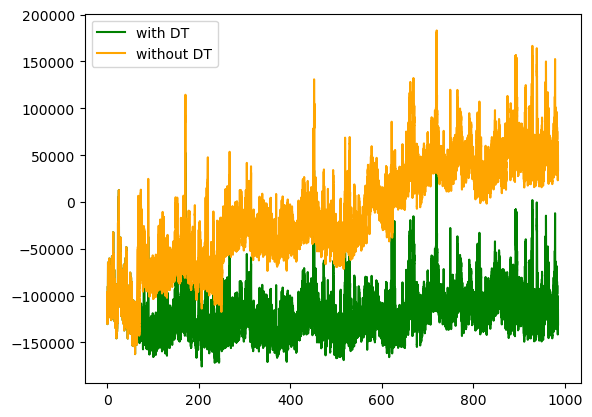

In [29]:
plt.plot(tt, corrected_tod[20], color='green', label='with DT')
plt.plot(tt, corrected_tod_nodt[20], color='orange', label='without DT')
plt.legend()

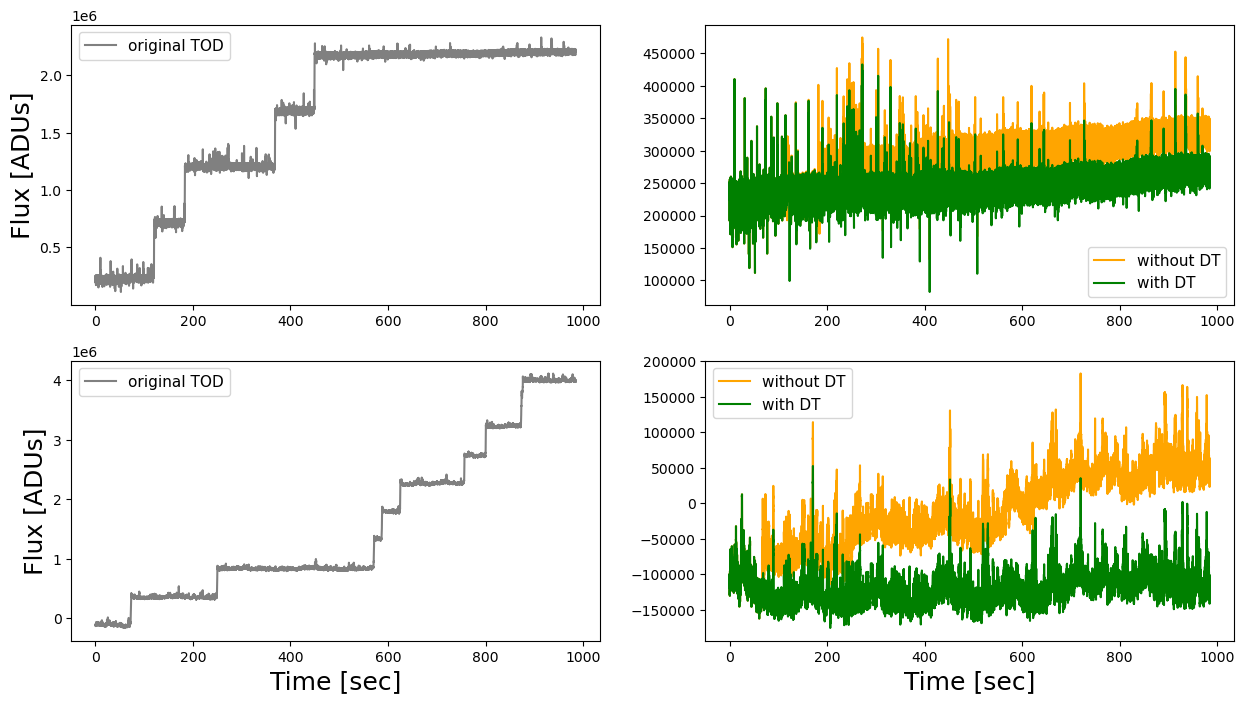

In [30]:
fig, ax = plt.subplots(2,2, figsize=(15, 8))

ax[0,0].plot(tt, todarray[55], color='gray', label='original TOD')
#ax[0,0].plot(tt, corrected_tod_nodt[55], color='orange', label='without DT')
#ax[0,0].plot(tt, corrected_tod[55], color='green', label='with DT')
ax[0,0].set_ylabel('Flux [ADUs]', fontsize=18)
#ax[0,0].set_xlabel('Time [sec]', fontsize=18)
ax[0,0].legend(fontsize=11)


#ax[0,1].plot(tt, todarray[55], color='gray', label='original TOD')
ax[0,1].plot(tt, corrected_tod_nodt[55], color='orange', label='without DT')
ax[0,1].plot(tt, corrected_tod[55], color='green', label='with DT')

#ax[0,1].set_ylabel('Flux [ADUs]', fontsize=18)
#ax[0,1].set_xlabel('Time [sec]', fontsize=18)
ax[0,1].legend(fontsize=11)

ax[1,0].plot(tt, todarray[20], color='gray', label='original TOD')
#ax[1,0].plot(tt, corrected_tod_nodt[55], color='orange', label='without DT')
#ax[1,0].plot(tt, corrected_tod[55], color='green', label='with DT')
ax[1,0].set_ylabel('Flux [ADUs]', fontsize=18)
ax[1,0].set_xlabel('Time [sec]', fontsize=18)
ax[1,0].legend(fontsize=11)

#ax[1,1].plot(tt, todarray[20], color='gray', label='original TOD')
ax[1,1].plot(tt, corrected_tod_nodt[20], color='orange', label='without DT')
ax[1,1].plot(tt, corrected_tod[20], color='green', label='with DT')

#ax[1,1].set_ylabel('Flux [ADUs]', fontsize=18)
ax[1,1].set_xlabel('Time [sec]', fontsize=18)
ax[1,1].legend(fontsize=11)


Text(0.5, 0, 'Time [sec]')

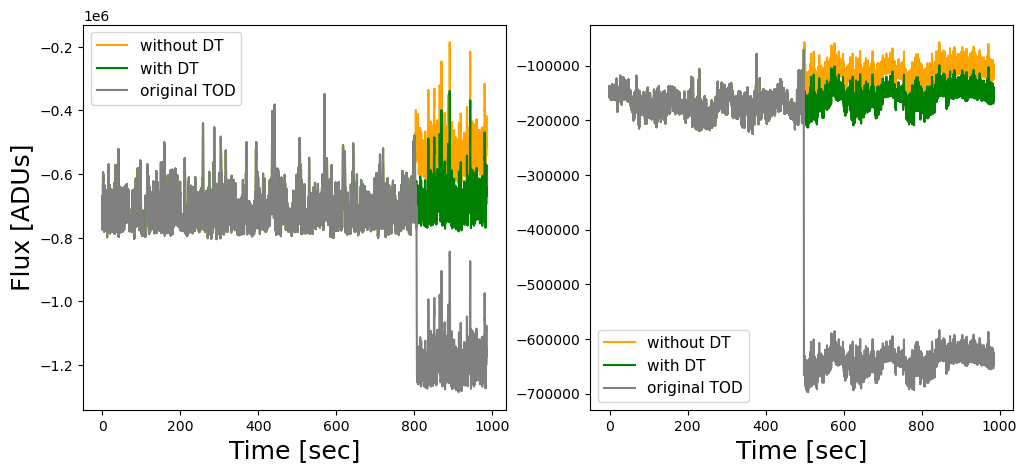

In [31]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))

ax[0].plot(tt, corrected_tod_nodt[254], color='orange', label='without DT')
ax[0].plot(tt, corrected_tod[254], color='green', label='with DT')
ax[0].plot(tt, todarray[254], color='gray', label='original TOD')

ax[0].set_xlabel('Time [sec]', fontsize=18)
ax[0].set_ylabel('Flux [ADUs]', fontsize=18)
ax[0].legend(fontsize=11)

ax[1].plot(tt, corrected_tod_nodt[205], color='orange', label='without DT')
ax[1].plot(tt, corrected_tod[205], color='green', label='with DT')
ax[1].plot(tt, todarray[205], color='gray', label='original TOD')

ax[1].legend(fontsize=11)
ax[1].set_xlabel('Time [sec]', fontsize=18)
#ax[1].set_ylabel('Flux [ADUs]', fontsize=18)

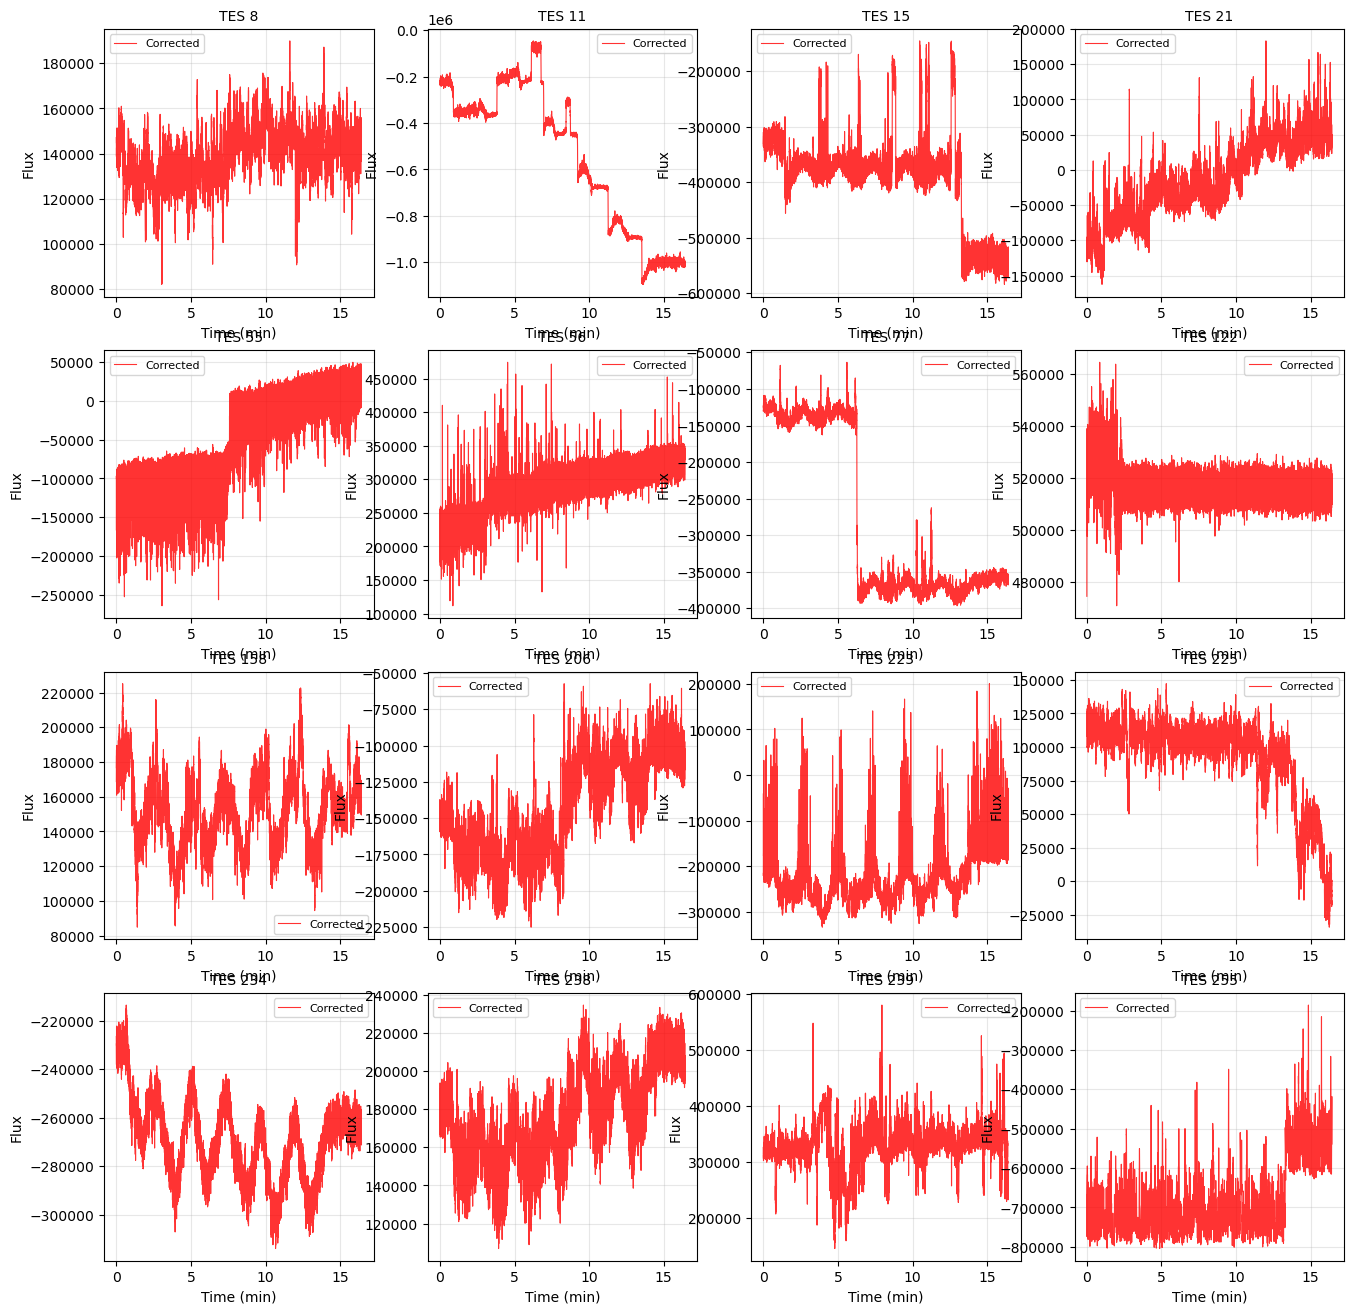

In [36]:
# correcciones sin usar DT

n_plot = len(TES_yes)
n_cols = 4
n_rows = int(np.ceil(n_plot / n_cols))
        
fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
if n_rows == 1:
    ax = ax.reshape(1, -1)
ax = ax.flatten()
        
plot_idx = 0
for idx in TES_yes[:n_plot]:
                
    if idx in corrected_tod_nodt:
        ax[plot_idx].plot(tt/60, corrected_tod_nodt[idx], 'r-', 
                          linewidth=0.8, label='Corrected', alpha=0.8)
                
        ax[plot_idx].set_title(f'TES {idx+1}', fontsize=10)
        ax[plot_idx].set_xlabel('Time (min)')
        ax[plot_idx].set_ylabel('Flux')
        ax[plot_idx].legend(fontsize=8)
        ax[plot_idx].grid(True, alpha=0.3)
        plot_idx += 1

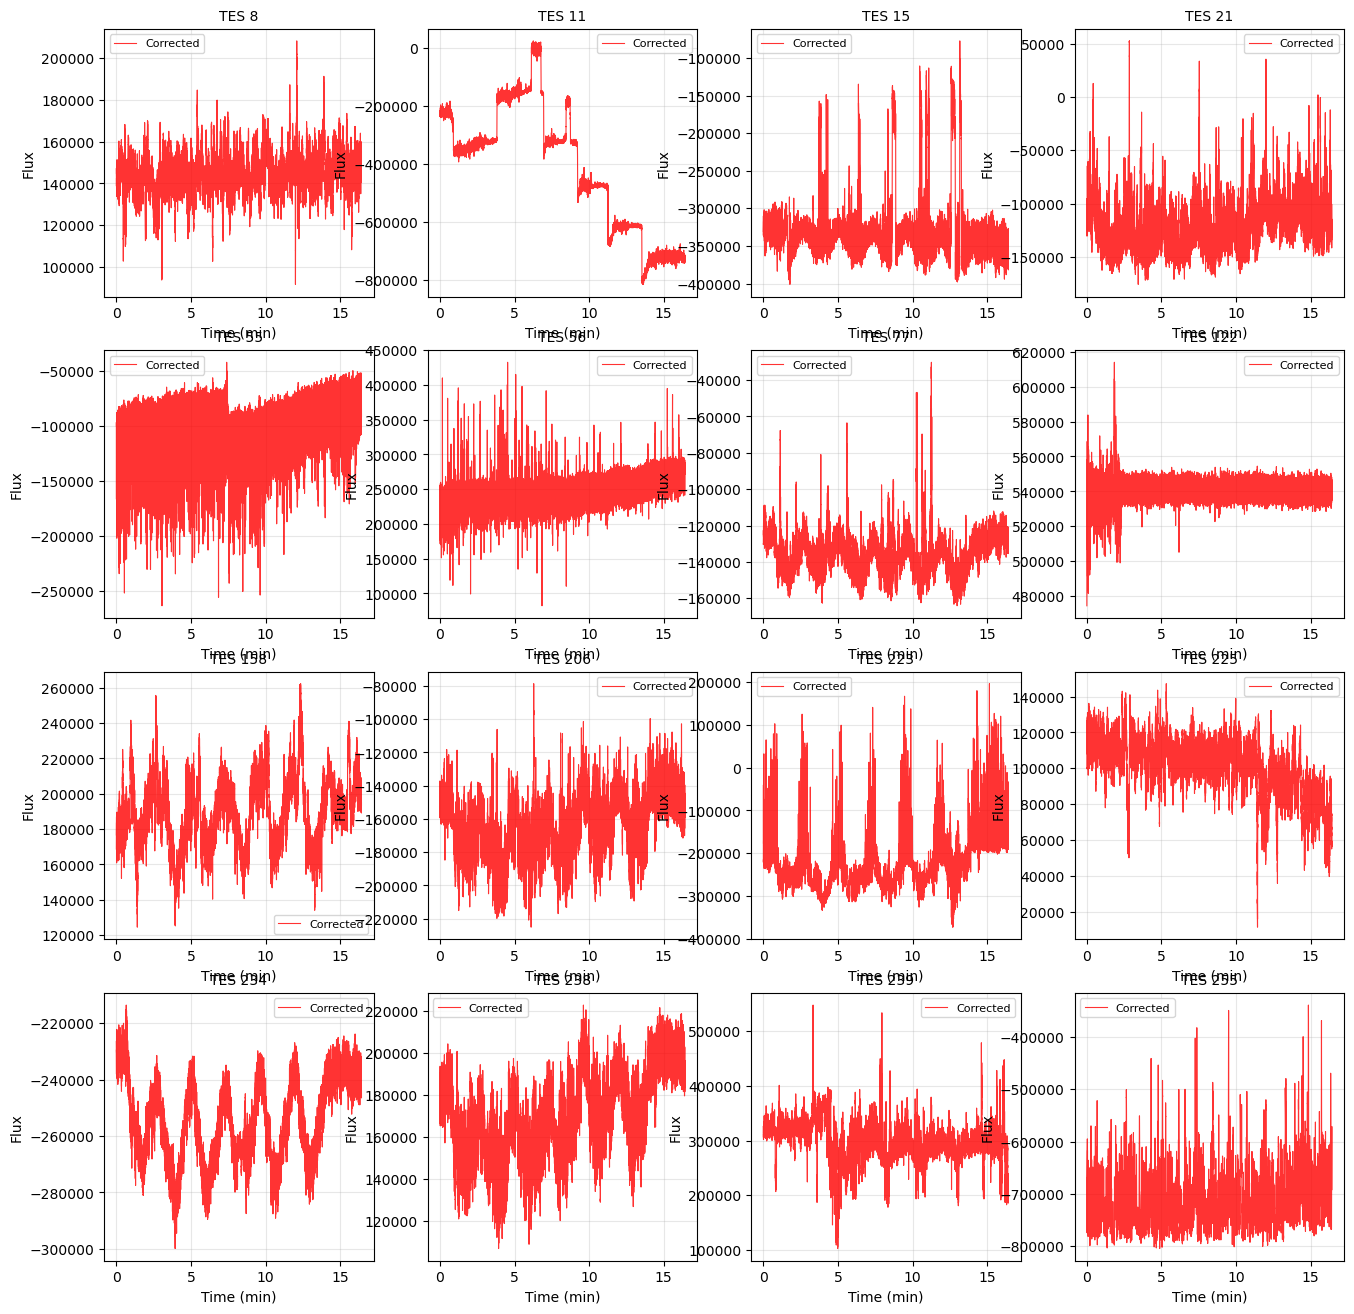

In [38]:
# correcciones usando DT

n_plot = len(TES_with_dt_jumps)
n_cols = 4
n_rows = int(np.ceil(n_plot / n_cols))
        
fig, ax = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
if n_rows == 1:
    ax = ax.reshape(1, -1)
ax = ax.flatten()
        
plot_idx = 0
for idx in TES_with_dt_jumps[:n_plot]:
                
    if idx in corrected_tod:
        ax[plot_idx].plot(tt/60, corrected_tod[idx], 'r-', 
                          linewidth=0.8, label='Corrected', alpha=0.8)
                
        ax[plot_idx].set_title(f'TES {idx+1}', fontsize=10)
        ax[plot_idx].set_xlabel('Time (min)')
        ax[plot_idx].set_ylabel('Flux')
        ax[plot_idx].legend(fontsize=8)
        ax[plot_idx].grid(True, alpha=0.3)
        plot_idx += 1

Text(0.5, 1.0, 'Detection with DT')

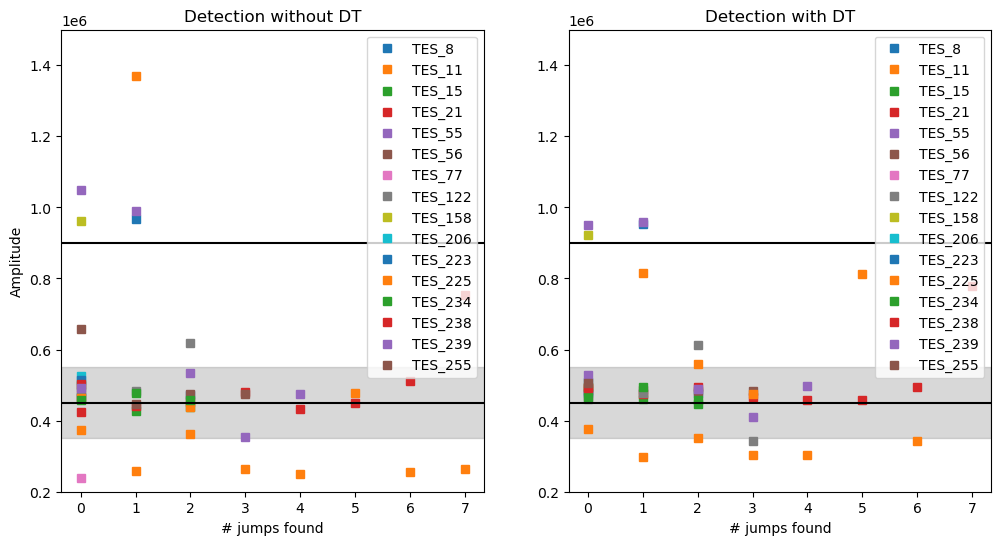

In [32]:
fig, ax = plt.subplots(1,2, figsize=(12,6))

for i in TES_with_dt_jumps:
    ax[0].plot(abs(np.asarray(offset_nodt[i])), marker='s', lw=0, label='TES_{}'.format(i+1))
    ax[0].legend(loc='upper right')
    
ax[0].axhspan(ymin=3.5e5, ymax=5.5e5, color='grey', alpha=0.3)
ax[0].axhline(y=4.5e5, color='black')
ax[0].axhline(y=9e5, color='black')

ax[0].set_ylim(2e5, 1.5e6)
ax[0].set_ylabel('Amplitude')
ax[0].set_xlabel('# jumps found')
ax[0].set_title('Detection without DT')

for i in TES_with_dt_jumps:
    ax[1].plot(abs(np.asarray(offset[i])), marker='s', lw=0, label='TES_{}'.format(i+1))
    ax[1].legend(loc='upper right')
    
ax[1].axhspan(ymin=3.5e5, ymax=5.5e5, color='grey', alpha=0.3)
ax[1].axhline(y=4.5e5, color='black')
ax[1].axhline(y=9e5, color='black')

ax[1].set_ylim(2e5, 1.5e6)
#ax[1].set_ylabel('Amplitude')
ax[1].set_xlabel('# jumps found')
ax[1].set_title('Detection with DT')